In [1]:
import fig01, fig05to06
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from drift_diffusion.model import DriftDiffusionModel

# notebook defaults
plt.rcParams.update({"font.size": 12, "font.family": "Helvetica", "savefig.transparent": True})

In [2]:
# !! specify whether to refit: 11min runtime !!
REFIT = False  # True to refit, False to load precomputed results

# load + preprocess
df195 = fig01.preproc_df()
df195_subset = df195.query("day > 35 and trial <= 800")

# fit DDM parameters
ddm = DriftDiffusionModel(
    a="bs(trial, df=3, degree=2)",
    t0="bs(trial, df=3, degree=2)",
    v="coherence + bs(trial, df=3, degree=2)",
    z="bs(trial, df=3, degree=2)",
    cov_estimator="autocorrelation-robust",
    verbose=True,
)

if REFIT:
    ddm.fit(df195_subset, df195_subset["y"], params0=np.load("results/ddm-splines-params.npy"))
else:
    ddm.params_ = np.load("results/ddm-splines-params.npy")
    ddm.covariance_ = np.load("results/ddm-splines-covs.npy")

a 0.7900596198015224 1.1960296965640451
t0 0.34653690329774733 0.46191732904585686
v 1.1855398778830941 1.7497166711779442
z -0.0021979453765710033 0.2889948528964464


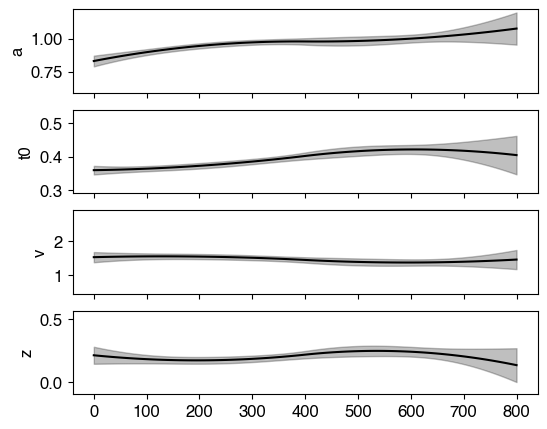

In [3]:
# plot DDM parameters as functions of trial and fixed coherence
coherence = np.repeat(1, 100)
trial_min, trial_max = df195_subset["trial"].min(), df195_subset["trial"].max()
trial = np.linspace(trial_min, trial_max, 100)
X = pd.DataFrame({"coherence": coherence, "trial": trial})

y_limits = fig05to06.get_y_limits()

# bonferroni correction for simultaneous confidence bands
g = ddm.g(X, alpha=0.05 / df195_subset["trial"].nunique())
fig, axs = plt.subplots(nrows=4, figsize=(6, 5), sharex=True)

for i, p in enumerate(["a", "t0", "v", "z"]):
    axs[i].fill_between(trial, g[p]["-"], g[p]["+"], color="k", alpha=0.25)
    axs[i].plot(trial, g[p]["g"], color="k")
    axs[i].set_ylabel(p)
    axs[i].set_ylim(y_limits[p])
    print(p, g[p]["-"].min(), g[p]["+"].max())

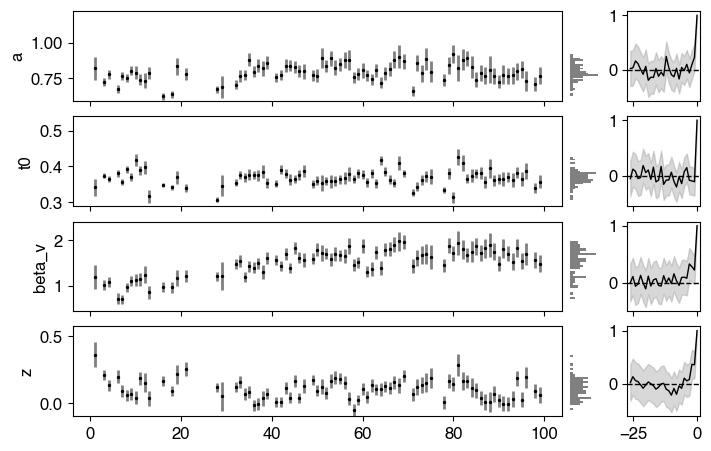

In [4]:
# fit splines by day with free intercept and fixed coefficients
ddm_fitby_day = fig05to06.fit_ddm_splines(df195, refit=REFIT)

fig, axs = plt.subplots(
    nrows=4, ncols=3, figsize=(7, 4.4), width_ratios=[10, 0.6, 1.5], sharex="col", layout="constrained"
)
fig05to06.plot_estimates(axs=axs[0], df=ddm_fitby_day, fitby="day", col="a")
fig05to06.plot_estimates(axs=axs[1], df=ddm_fitby_day, fitby="day", col="t0")
fig05to06.plot_estimates(axs=axs[2], df=ddm_fitby_day, fitby="day", col="beta_v")
fig05to06.plot_estimates(axs=axs[3], df=ddm_fitby_day, fitby="day", col="z")